# 数据集样式
train:训练数据 里面只有一个正常样本good
test：测试图片  里面有很多文件夹既有good，也有hole等很多不同却显得文件夹
        在这里只做二分类，所以
        test/crack/*
        test/scratch/*
        ...
        都归属为Defect
ground_truth： 缺陷位置的标注。一般都是缺陷区域的mask（掩膜）。主要用于缺陷定位/分割/像素级评价，本次不用


Step 1：加载 train/good
Step 2：ResNet18 去掉最后分类层
Step 3：提取正常图片 feature
Step 4：计算正常 feature 中心
Step 5：读取 test
Step 6：计算 anomaly score
Step 7：确定 threshold
Step 8：输出 Good / Non-Good


In [30]:
import os.path
from xml.sax.handler import all_features

from torchvision import datasets, transforms
import torch

device = torch.device("mps" if torch.mps.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(
    "dataset/leather/train",
    transform = transform
)
print("加载全数据集完成。。。")
print("总样本数：",len(train_dataset))
print("类别：",train_dataset.classes)
print("类别映射：",train_dataset.class_to_idx)

加载全数据集完成。。。
总样本数： 245
类别： ['good']
类别映射： {'good': 0}


In [31]:
from torchvision import models
model = models.resnet18(weights = models.ResNet18_Weights.DEFAULT)

# 去掉最后的全连接分类层  这里是直接获取前一层的512维特征，不要输出1000个分类的logits
model.fc = torch.nn.Identity()

model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [32]:
image,label = train_dataset[0]
image = image.unsqueeze(0).to(device)

with torch.no_grad():
    feature = model(image)
print("feature shape:",feature.shape)

feature shape: torch.Size([1, 512])


In [33]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset= train_dataset,
    batch_size=32,
    shuffle=False,
)

all_features = []

with torch.no_grad():
    for images,labels in train_loader:
        images = images.to(device)
        features = model(images)
        all_features.append(features.cpu())
all_features = torch.cat(all_features,dim=0)
print("特征 feature shape:",all_features.shape)

特征 feature shape: torch.Size([245, 512])


In [34]:
normal_center = all_features.mean(dim=0)
print("正常特征中心 shape:", normal_center.shape)

正常特征中心 shape: torch.Size([512])


In [35]:
# 自定义dataset
from torch.utils.data import Dataset
from PIL import Image
class MVTecTestDataTest(Dataset):
    def __init__(self,root,transform=None):
        self.root = root
        self.transform = transform

        self.samples = []

        for defect_type in sorted(os.listdir(root)):
            defect_dir = os.path.join(root,defect_type)

            if not os.path.isdir(defect_dir):
                continue
            # 除了good都是1
            label = 0 if defect_type=='good' else 1

            for filename in sorted(os.listdir(defect_dir)):
                if filename.lower().endswith((".png",".jpg",".jpeg")):
                    image_path = os.path.join(defect_dir,filename)
                    self.samples.append((image_path,label,defect_type))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path,label,defect_type = self.samples[index]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image,label,defect_type,image_path

In [36]:
test_dataset = MVTecTestDataTest(
    'dataset/leather/test',
    transform = transform
)
print("测试集数据：",len(test_dataset))
for i in range(5):
    image, label, defect_type, path = test_dataset[i]

    print(
        "label:", label,
        "type:", defect_type,
        "path:", path
    )

测试集数据： 124
label: 1 type: color path: dataset/leather/test/color/000.png
label: 1 type: color path: dataset/leather/test/color/001.png
label: 1 type: color path: dataset/leather/test/color/002.png
label: 1 type: color path: dataset/leather/test/color/003.png
label: 1 type: color path: dataset/leather/test/color/004.png


# 计算欧氏距离

In [37]:
import torch

test_dataloader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

all_scores = []
all_labels = []
all_types = []

with torch.no_grad():
    for images,labels,defect_types,paths in test_dataloader:
        images = images.to(device)

        features = model(images)

        # 计算欧式距离
        distances = torch.norm(
            features.cpu() - normal_center,
            dim =1,
        )
        all_scores.extend(distances.tolist())
        all_labels.extend(labels.tolist())
        all_types.extend(defect_types)
print("测试图片数量：", len(all_scores))
print(all_scores[:20])

测试图片数量： 124
[9.228693962097168, 6.195632457733154, 4.550653457641602, 5.321618556976318, 3.3247575759887695, 4.92164945602417, 4.516369819641113, 3.9723873138427734, 8.373760223388672, 3.890254020690918, 3.925706624984741, 5.049832344055176, 4.96828031539917, 3.6175553798675537, 4.040397644042969, 6.994935512542725, 4.200689792633057, 5.852313041687012, 4.332065582275391, 5.525148391723633]


# 分别统计Good和Non-Good


In [38]:
import numpy as np
good_scores = [
    score for score,label in zip(all_scores,all_labels)
    if label==0
]
non_good_scores = [
    score for score,label in zip(all_scores,all_labels)
    if label==1
]
print("Good 数量：", len(good_scores))
print("Non-Good 数量：", len(non_good_scores))

print("\nGood:")
print("最小值：", np.min(good_scores))
print("最大值：", np.max(good_scores))
print("平均值：", np.mean(good_scores))

print("\nNon-Good:")
print("最小值：", np.min(non_good_scores))
print("最大值：", np.max(non_good_scores))
print("平均值：", np.mean(non_good_scores))

Good 数量： 32
Non-Good 数量： 92

Good:
最小值： 2.3214187622070312
最大值： 4.575098037719727
平均值： 3.388480342924595

Non-Good:
最小值： 1.8832916021347046
最大值： 16.812070846557617
平均值： 6.138614303391913


# 观察结果
观察结果发现这两类分数有着明显重叠


In [39]:
results = []

for score,label,defect_type ,path in zip(all_scores,all_labels,all_types,[item[0] for item in test_dataset.samples]):
    results.append({
        "score":score,
        "label":label,
        "type":defect_type,
        "path":path
    })
results = sorted(results,key=lambda  x: x["score"])
print("分数最低的15个图片")
for item in results[:15]:
    print(item)

print("分数最高的15个图片")
for item in results[-15:]:
    print(item)

分数最低的15个图片
{'score': 1.8832916021347046, 'label': 1, 'type': 'glue', 'path': 'dataset/leather/test/glue/004.png'}
{'score': 2.2219736576080322, 'label': 1, 'type': 'cut', 'path': 'dataset/leather/test/cut/014.png'}
{'score': 2.2618627548217773, 'label': 1, 'type': 'cut', 'path': 'dataset/leather/test/cut/009.png'}
{'score': 2.3214187622070312, 'label': 0, 'type': 'good', 'path': 'dataset/leather/test/good/004.png'}
{'score': 2.5666141510009766, 'label': 0, 'type': 'good', 'path': 'dataset/leather/test/good/003.png'}
{'score': 2.585963249206543, 'label': 0, 'type': 'good', 'path': 'dataset/leather/test/good/021.png'}
{'score': 2.606536865234375, 'label': 0, 'type': 'good', 'path': 'dataset/leather/test/good/000.png'}
{'score': 2.6707088947296143, 'label': 0, 'type': 'good', 'path': 'dataset/leather/test/good/023.png'}
{'score': 2.7284963130950928, 'label': 0, 'type': 'good', 'path': 'dataset/leather/test/good/010.png'}
{'score': 2.753044366836548, 'label': 0, 'type': 'good', 'path': 'da

# 小步结论
目前看到有重叠区间，现在判断如何设置阈值
此时同样的又用到混淆矩阵

In [40]:
import numpy as np

scores = np.array(all_scores)
labels = np.array(all_labels)
print("threshold | TP | TN | FP | FN | Recall | Precision | F1")

for threshold in np.arange(1.0, 10.1, 0.5):

    # 分数 >= threshold → 判定为 Non-Good
    predictions = (scores >= threshold).astype(int)

    TP = np.sum((predictions == 1) & (labels == 1))
    TN = np.sum((predictions == 0) & (labels == 0))
    FP = np.sum((predictions == 1) & (labels == 0))
    FN = np.sum((predictions == 0) & (labels == 1))

    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    print(
        f"{threshold:8.1f} | "
        f"{TP:2d} | {TN:2d} | {FP:2d} | {FN:2d} | "
        f"{recall:.3f} | {precision:.3f} | {f1:.3f}"
    )

threshold | TP | TN | FP | FN | Recall | Precision | F1
     1.0 | 92 |  0 | 32 |  0 | 1.000 | 0.742 | 0.852
     1.5 | 92 |  0 | 32 |  0 | 1.000 | 0.742 | 0.852
     2.0 | 91 |  0 | 32 |  1 | 0.989 | 0.740 | 0.847
     2.5 | 89 |  1 | 31 |  3 | 0.967 | 0.742 | 0.840
     3.0 | 88 | 13 | 19 |  4 | 0.957 | 0.822 | 0.884
     3.5 | 85 | 20 | 12 |  7 | 0.924 | 0.876 | 0.899
     4.0 | 76 | 24 |  8 | 16 | 0.826 | 0.905 | 0.864
     4.5 | 62 | 31 |  1 | 30 | 0.674 | 0.984 | 0.800
     5.0 | 50 | 32 |  0 | 42 | 0.543 | 1.000 | 0.704
     5.5 | 43 | 32 |  0 | 49 | 0.467 | 1.000 | 0.637
     6.0 | 30 | 32 |  0 | 62 | 0.326 | 1.000 | 0.492
     6.5 | 25 | 32 |  0 | 67 | 0.272 | 1.000 | 0.427
     7.0 | 22 | 32 |  0 | 70 | 0.239 | 1.000 | 0.386
     7.5 | 21 | 32 |  0 | 71 | 0.228 | 1.000 | 0.372
     8.0 | 20 | 32 |  0 | 72 | 0.217 | 1.000 | 0.357
     8.5 | 17 | 32 |  0 | 75 | 0.185 | 1.000 | 0.312
     9.0 | 16 | 32 |  0 | 76 | 0.174 | 1.000 | 0.296
     9.5 | 13 | 32 |  0 | 79 | 0.141 | 1.00

TP = 坏品 → 成功识别为坏品  true Positive 正确识别成了目标类

TN = 好品 → 成功识别为好品  true Negative  正确识别成了非目标类

FP = 好品 → 错判成坏品      false positive 错误的识别成了目标类
FN = 坏品 → 错判成好品      true negative  正确的识别成了非目标类

In [41]:
import pandas as pd

for threshold in [2.5,3.0]:

    fn_results = [
        item for item in results
        if item["label"] == 1 and item["score"] < threshold
    ]

    print(f"\n===== threshold = {threshold} =====")
    print("漏检数量：", len(fn_results))

    # 统计每种缺陷漏检数量
    defect_count = {}

    for item in fn_results:
        defect_type = item["type"]
        defect_count[defect_type] = defect_count.get(defect_type, 0) + 1

    print("各缺陷类型漏检情况：")

    for defect_type, count in defect_count.items():
        print(f"{defect_type:>6}: {count}")


===== threshold = 2.5 =====
漏检数量： 3
各缺陷类型漏检情况：
  glue: 1
   cut: 2

===== threshold = 3.0 =====
漏检数量： 4
各缺陷类型漏检情况：
  glue: 1
   cut: 3


# 分析
肉眼还差错误图片，发现这些图片的异常区域都非常小。
因为本身用的是整个图的特征值，所以如果异常区域比较小，那么特征值是判断不出来的。
特征图输出的512维特征是对图片整体信息的高度压缩表示，所以可能最后会被稀释，而且我们的输入图片都会被resize。

下一步我们从global转换成patch

# 开始PatchCore
核心思想：从 CNN 中间层提取局部 Patch 特征，建立“正常 Patch 特征库”，再用最近邻距离判断测试 Patch 是否异常。
patchCore其实有限制的，基本上要固定位置、焦距。相对位置要大部分一致。如果训练都有立着的物体，识别用倾斜45°的就肯定不行。

In [42]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = torch.nn.Identity()
model = model.to(device)
model.eval()
def extract_feature_map(x):

    x = model.conv1(x)
    x = model.bn1(x)
    x = model.relu(x)
    x = model.maxpool(x)

    x = model.layer1(x)
    x = model.layer2(x)
    x = model.layer3(x)

    return x

images, labels = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    feature_map = extract_feature_map(images)

print(feature_map.shape)
patch_features = feature_map.permute(0, 2, 3, 1)

print("patch features:", patch_features.shape)

torch.Size([32, 256, 14, 14])
patch features: torch.Size([32, 14, 14, 256])


In [43]:
all_patch_features = []
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)

        feature_map = extract_feature_map(images)
        # 在模型里默认的数据为  B C H W  这里改成 B H W C  此时通道放在最后面，表示每个空间位置都有一个256维特征
        patch_features = feature_map.permute(0,2,3,1)

        patch_features = patch_features.reshape(-1,256)

        all_patch_features.append(patch_features.cpu())
all_patch_features = torch.cat(all_patch_features,dim=0)# dim=0 纵向拼接（增加行数） dim=1 横向拼接累加（增加列数）
print(all_patch_features.shape)

torch.Size([48020, 256])


这里我们把目前256个图片×196个patch=50176个patch特征（其中每个patch里面都是256维特征）的特征库。这是一个全集！
现在我们已经拿到了50176个patch特征值了。现在就是判断测试图片和这些50176个不同patch做比较，判断距离

In [44]:
# 取测试集第一张图片
image, label, defect_type, path = test_dataset[0]

image = image.unsqueeze(0).to(device)

with torch.no_grad():
    feature_map = extract_feature_map(image)

    # [1, 256, 14, 14]
    patch_features = feature_map.permute(0, 2, 3, 1)

    # [1, 14, 14, 256]
    patch_features = patch_features.reshape(-1, 256)

print("test patch features:", patch_features.shape)
# 判断距离
distances = torch.cdist(
    patch_features.cpu(),
    all_patch_features
)

print(distances.shape)

test patch features: torch.Size([196, 256])
torch.Size([196, 48020])


现在目标图片经过模型以后会生成196个patch（里面也是256维），分别和50176个正常patch算距离。
同时取最小值。

为什么取最小值？因为我们要回答的问题是 这个测试patch像不像某个正常的patch
只要能找到一个非常像的patch就行。所以我们取最小值，这就是最近邻距离。

第二次对196个patch取max，这是想要知道“这张图片有没有某一个局部区域非常异常”
然后得到一个max值。这代表这张图片存在一个局部区域，在正常特征库里很难找到相似区域。

In [45]:
nearest_distances = distances.min(dim=1).values

print(nearest_distances.shape)
print(nearest_distances)

anomaly_score = nearest_distances.max()

print("anomaly score:", anomaly_score.item())

torch.Size([196])
tensor([1.4522, 1.3092, 1.2877, 1.1594, 1.1921, 0.9740, 1.0004, 1.0751, 1.1725,
        1.0468, 1.1871, 1.2329, 1.5986, 1.7125, 1.1267, 1.0535, 1.0251, 0.8787,
        0.8907, 0.7845, 0.8740, 0.8387, 0.8804, 0.9524, 0.9723, 1.0335, 1.2117,
        1.1798, 1.2108, 0.9786, 0.9127, 0.7959, 0.8005, 0.7535, 0.7738, 0.7154,
        0.8403, 0.8685, 0.9536, 0.9562, 1.1417, 1.0898, 1.1332, 0.9837, 0.8805,
        0.7799, 0.7066, 0.6394, 0.7540, 0.7709, 0.7872, 0.8667, 0.8406, 0.8592,
        0.9552, 1.0094, 1.2619, 1.0719, 0.9490, 0.8175, 0.9194, 0.8048, 0.7016,
        0.8393, 0.9287, 1.0404, 0.9444, 0.9131, 1.1011, 1.0101, 1.1162, 0.9132,
        0.9166, 0.8093, 0.8767, 0.8680, 0.9258, 0.9562, 1.2858, 1.5956, 1.4065,
        1.1560, 1.1111, 0.9779, 1.1774, 0.9680, 0.8939, 0.9047, 0.7711, 0.8802,
        0.9640, 1.1994, 1.9061, 2.5614, 1.7839, 1.3152, 1.1397, 1.0177, 1.1010,
        0.9279, 0.8659, 0.8189, 0.6656, 0.6923, 0.8401, 1.2829, 2.1031, 4.4164,
        3.0150, 1.4924

In [46]:
if anomaly_score >= threshold:
    print("Anomaly")
else:
    print("Good")

Anomaly


In [47]:
patch_results = []

with torch.no_grad():

    for image, label, defect_type, path in test_dataset:

        image = image.unsqueeze(0).to(device)

        # [1, 256, 14, 14]
        feature_map = extract_feature_map(image)

        # [1, 14, 14, 256]
        patch_features = feature_map.permute(0, 2, 3, 1)

        # [196, 256]
        patch_features = patch_features.reshape(-1, 256)

        # [196, 50176]
        distances = torch.cdist(
            patch_features.cpu(),
            all_patch_features
        )

        # 每个测试 Patch 到最近正常 Patch 的距离
        # [196]
        nearest_distances = distances.min(dim=1).values

        # 整张图片的 anomaly score
        anomaly_score = nearest_distances.max().item()

        patch_results.append({
            "score": anomaly_score,
            "label": label,
            "type": defect_type,
            "path": path
        })

In [48]:
from collections import defaultdict
import numpy as np

type_scores = defaultdict(list)

for item in patch_results:
    type_scores[item["type"]].append(item["score"])

for defect_type, scores in type_scores.items():

    print(
        defect_type,
        "min:", round(min(scores), 3),
        "max:", round(max(scores), 3),
        "mean:", round(np.mean(scores), 3)
    )

color min: 1.925 max: 4.734 mean: 3.274
cut min: 2.151 max: 5.096 mean: 3.532
fold min: 2.139 max: 4.315 mean: 2.97
glue min: 1.967 max: 8.435 mean: 5.863
good min: 1.319 max: 2.082 mean: 1.514
poke min: 3.025 max: 5.688 mean: 3.813


In [49]:
import numpy as np

scores = np.array([
    item["score"]
    for item in patch_results
])

labels = np.array([
    item["label"]
    for item in patch_results
])

print("threshold | TP | TN | FP | FN | Recall | Precision | F1")

for threshold in np.arange(1.5, 6.1, 0.2):

    predictions = (scores >= threshold).astype(int)

    TP = np.sum((predictions == 1) & (labels == 1))
    TN = np.sum((predictions == 0) & (labels == 0))
    FP = np.sum((predictions == 1) & (labels == 0))
    FN = np.sum((predictions == 0) & (labels == 1))

    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0
        else 0
    )

    print(
        f"{threshold:8.2f} | "
        f"{TP:2d} | "
        f"{TN:2d} | "
        f"{FP:2d} | "
        f"{FN:2d} | "
        f"{recall:.3f} | "
        f"{precision:.3f} | "
        f"{f1:.3f}"
    )

threshold | TP | TN | FP | FN | Recall | Precision | F1
    1.50 | 92 | 18 | 14 |  0 | 1.000 | 0.868 | 0.929
    1.70 | 92 | 29 |  3 |  0 | 1.000 | 0.968 | 0.984
    1.90 | 92 | 30 |  2 |  0 | 1.000 | 0.979 | 0.989
    2.10 | 89 | 32 |  0 |  3 | 0.967 | 1.000 | 0.983
    2.30 | 83 | 32 |  0 |  9 | 0.902 | 1.000 | 0.949
    2.50 | 81 | 32 |  0 | 11 | 0.880 | 1.000 | 0.936
    2.70 | 75 | 32 |  0 | 17 | 0.815 | 1.000 | 0.898
    2.90 | 67 | 32 |  0 | 25 | 0.728 | 1.000 | 0.843
    3.10 | 58 | 32 |  0 | 34 | 0.630 | 1.000 | 0.773
    3.30 | 53 | 32 |  0 | 39 | 0.576 | 1.000 | 0.731
    3.50 | 50 | 32 |  0 | 42 | 0.543 | 1.000 | 0.704
    3.70 | 38 | 32 |  0 | 54 | 0.413 | 1.000 | 0.585
    3.90 | 30 | 32 |  0 | 62 | 0.326 | 1.000 | 0.492
    4.10 | 29 | 32 |  0 | 63 | 0.315 | 1.000 | 0.479
    4.30 | 27 | 32 |  0 | 65 | 0.293 | 1.000 | 0.454
    4.50 | 21 | 32 |  0 | 71 | 0.228 | 1.000 | 0.372
    4.70 | 19 | 32 |  0 | 73 | 0.207 | 1.000 | 0.342
    4.90 | 17 | 32 |  0 | 75 | 0.185 | 1.00

现在调成2.3的阈值看看FN的数据，即错误认定为good的这些图片

In [50]:
global_threshold = 2.3

global_fn = [
    r for r in patch_results
    if r["label"] == 1 and r["score"] <= global_threshold
]

print("Global FN:", len(global_fn))

for r in global_fn:
    print(r["type"], r["score"], r["path"])

Global FN: 9
color 2.0090396404266357 dataset/leather/test/color/004.png
color 2.2249679565429688 dataset/leather/test/color/007.png
color 1.925279974937439 dataset/leather/test/color/009.png
cut 2.2165753841400146 dataset/leather/test/cut/002.png
cut 2.1505062580108643 dataset/leather/test/cut/009.png
cut 2.193599224090576 dataset/leather/test/cut/014.png
fold 2.138637065887451 dataset/leather/test/fold/010.png
glue 1.9665189981460571 dataset/leather/test/glue/004.png
glue 2.100376605987549 dataset/leather/test/glue/010.png


In [51]:
# 把FN的patch分数对应起来
patch_dict = {
    r["path"]: r["score"]
    for r in patch_results
}

for r in global_fn:

    patch_score = patch_dict[r["path"]]

    print(
        f"type={r['type']:<6} "
        f"global={r['score']:.3f} "
        f"patch={patch_score:.3f} "
        f"{r['path']}"
    )

type=color  global=2.009 patch=2.009 dataset/leather/test/color/004.png
type=color  global=2.225 patch=2.225 dataset/leather/test/color/007.png
type=color  global=1.925 patch=1.925 dataset/leather/test/color/009.png
type=cut    global=2.217 patch=2.217 dataset/leather/test/cut/002.png
type=cut    global=2.151 patch=2.151 dataset/leather/test/cut/009.png
type=cut    global=2.194 patch=2.194 dataset/leather/test/cut/014.png
type=fold   global=2.139 patch=2.139 dataset/leather/test/fold/010.png
type=glue   global=1.967 patch=1.967 dataset/leather/test/glue/004.png
type=glue   global=2.100 patch=2.100 dataset/leather/test/glue/010.png


这5个图片就是 其实是缺陷图片，但却被识别成good的图片。通过图片观察可以看到，有的是异常区域很小，有的是异常区域细长。

In [52]:
# 转换成 图片路径-分数的字典
patch_dict = {
    item["path"]: item["score"]
    for item in patch_results
}

print("Global vs Patch")

for item in results:
    # 遍历，根据图片路径找到对应的patch分数
    patch_score = patch_dict[item["path"]]

    print(
        f"{item['path']:<45} "
        f"Global={item['score']:.10f} "
        f"Patch={patch_score:.10f}"
    )

Global vs Patch
dataset/leather/test/glue/004.png             Global=1.8832916021 Patch=1.9665189981
dataset/leather/test/cut/014.png              Global=2.2219736576 Patch=2.1935992241
dataset/leather/test/cut/009.png              Global=2.2618627548 Patch=2.1505062580
dataset/leather/test/good/004.png             Global=2.3214187622 Patch=1.5965201855
dataset/leather/test/good/003.png             Global=2.5666141510 Patch=1.4567068815
dataset/leather/test/good/021.png             Global=2.5859632492 Patch=1.3854933977
dataset/leather/test/good/000.png             Global=2.6065368652 Patch=1.6746301651
dataset/leather/test/good/023.png             Global=2.6707088947 Patch=1.4169231653
dataset/leather/test/good/010.png             Global=2.7284963131 Patch=1.5986127853
dataset/leather/test/good/015.png             Global=2.7530443668 Patch=1.5828158855
dataset/leather/test/good/017.png             Global=2.7563366890 Patch=1.4039884806
dataset/leather/test/good/019.png             Glo

现在开始做异常热力图
这张图片“哪里最像异常”
我们最后计算的时候是拿到196（坐标为 14 ×14）个patch。

其实看热力图就是为了确认下热力图展示的异常点和实际图片的异常点是否一致。
如果不一致就要接下来去思考新问题：
1. 这是偶然还是系统性必然？
2. 这是对于某一些异常展示不出来异常还是全部都异常？


In [53]:
import torch.nn.functional as F

anomaly_map = nearest_distances.reshape(1, 1, 14, 14)
# 原始patch 只有14×14 ，这里需要扩展到224
anomaly_map = F.interpolate(
    anomaly_map,
    size=(224, 224),
    mode="bilinear",
    align_corners=False
)

anomaly_map = anomaly_map.squeeze()

print(anomaly_map.shape)
print(anomaly_map.max())
print(anomaly_map.min())



torch.Size([224, 224])
tensor(3.1435)
tensor(0.7791)


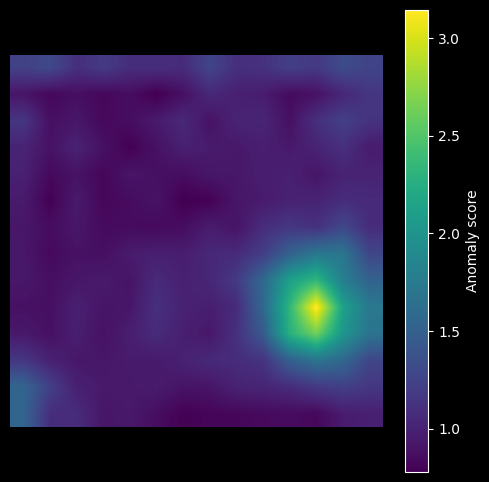

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.imshow(
    anomaly_map.detach().cpu().numpy()
)

plt.colorbar(label="Anomaly score")
plt.axis("off")
plt.show()

现在做threshold的校准
1. 先用正常数据跑一遍然后判断阈值分布


In [55]:
normal_scores = []

with torch.no_grad():

    for images, labels in train_loader:

        images = images.to(device)

        # [B, 256, 14, 14]
        feature_map = extract_feature_map(images)

        # [B, 14, 14, 256]
        patch_features = feature_map.permute(0, 2, 3, 1)

        # [B*196, 256]
        patch_features = patch_features.reshape(-1, 256)

        # 这里要注意：
        # 如果 batch_size=32，那么这里是 [6272, 50176]
        distances = torch.cdist(
            patch_features.cpu(),
            all_patch_features
        )

        # 每个 Patch 找最近的正常 Patch
        # [B*196]
        nearest_distances = distances.min(dim=1).values

        # 恢复成每张图片 196 个 Patch
        nearest_distances = nearest_distances.reshape(
            images.shape[0],
            196
        )

        # 每张图片取最异常的 Patch
        # [B]
        anomaly_scores = nearest_distances.max(dim=1).values

        normal_scores.extend(
            anomaly_scores.tolist()
        )

import numpy as np

normal_scores = np.array(normal_scores)

print("数量:", len(normal_scores))
print("最小:", normal_scores.min())
print("最大:", normal_scores.max())
print("平均:", normal_scores.mean())
print("中位数:", np.median(normal_scores))
print("95%:", np.percentile(normal_scores, 95))
print("99%:", np.percentile(normal_scores, 99))

数量: 245
最小: 0.0023920799139887094
最大: 0.005167482886463404
平均: 0.003359225935929892
中位数: 0.0033829116728156805
95%: 0.00390625
99%: 0.004600750450044871


以上可以看到所有的距离基本为0或者分数尤其低，这是个非常好、正常的现象。
因为我们是用正常图片简历的patch库，然后我们又用这些图片去再次匹配，所以得到的数据基本都是0.
但这里其实我们应该是用另外一批没有用过的good数据去匹配尝试。

接下来我们拆分训练数据，一部分数据用来建立patch库，一部分用来验证。

In [59]:
from torch.utils.data import random_split

patch_bank_dataset, calibration_dataset = random_split(
    train_dataset,
    [200, 45],
    generator=torch.Generator().manual_seed(42)
)

print(len(patch_bank_dataset))
print(len(calibration_dataset))
from torch.utils.data import random_split

patch_bank_dataset, calibration_dataset = random_split(
    train_dataset,
    [200, 45],
    generator=torch.Generator().manual_seed(42)
)

print("Patch Bank:", len(patch_bank_dataset))
print("Calibration:", len(calibration_dataset))

200
45
Patch Bank: 200
Calibration: 45


建立patch bank

In [60]:
from torch.utils.data import DataLoader

patch_bank_loader = DataLoader(
    patch_bank_dataset,
    batch_size=32,
    shuffle=False
)

all_patch_features = []

with torch.no_grad():
    for images, labels in patch_bank_loader:

        images = images.to(device)

        # [B, 256, 14, 14]
        feature_map = extract_feature_map(images)

        # [B, 14, 14, 256]
        patch_features = feature_map.permute(0, 2, 3, 1)

        # [B*196, 256]
        patch_features = patch_features.reshape(-1, 256)

        all_patch_features.append(
            patch_features.cpu()
        )

all_patch_features = torch.cat(
    all_patch_features,
    dim=0
)

print(all_patch_features.shape)

torch.Size([39200, 256])


验证数据集去测试Patch Bank

In [61]:
calibration_loader = DataLoader(
    calibration_dataset,
    batch_size=1,
    shuffle=False
)

calibration_scores = []

with torch.no_grad():

    for images, labels in calibration_loader:

        images = images.to(device)

        # [1, 256, 14, 14]
        feature_map = extract_feature_map(images)

        # [1, 14, 14, 256]
        patch_features = feature_map.permute(0, 2, 3, 1)

        # [196, 256]
        patch_features = patch_features.reshape(-1, 256)

        # [196, 39200]
        distances = torch.cdist(
            patch_features.cpu(),
            all_patch_features
        )

        # 每个测试 Patch 找最近的正常 Patch
        # [196]
        nearest_distances = distances.min(dim=1).values

        # 一张图片的 anomaly score
        anomaly_score = nearest_distances.max().item()

        calibration_scores.append(anomaly_score)


calibration_scores = torch.tensor(calibration_scores)

print("数量:", len(calibration_scores))
print("最小:", calibration_scores.min().item())
print("最大:", calibration_scores.max().item())
print("平均:", calibration_scores.mean().item())
print("中位数:", calibration_scores.median().item())
print("95%:", torch.quantile(calibration_scores, 0.95).item())
print("99%:", torch.quantile(calibration_scores, 0.99).item())

数量: 45
最小: 1.1668095588684082
最大: 1.7842270135879517
平均: 1.3401790857315063
中位数: 1.329958438873291
95%: 1.5172061920166016
99%: 1.7367606163024902


此时展示选择95%这里 threshold ≈ 1.52

那么生产就可以写
if anomaly_score > threshold:
    print("异常")
else:
    print("正常")

当然，这只是我们根据验证good数据集得出的临时结论，现在我们要对test进行检测，得到他们的分数后，我们再去判断阈值到底设置多少比较合适。

In [62]:
patch_results = []

with torch.no_grad():

    for image, label, defect_type, path in test_dataset:

        image = image.unsqueeze(0).to(device)

        # [1, 256, 14, 14]
        feature_map = extract_feature_map(image)

        # [1, 14, 14, 256]
        patch_features = feature_map.permute(0, 2, 3, 1)

        # [196, 256]
        patch_features = patch_features.reshape(-1, 256)

        # [196, 39200]
        distances = torch.cdist(
            patch_features.cpu(),
            all_patch_features
        )

        # 每个 Patch 到正常 Patch Bank 的最近距离
        # [196]
        nearest_distances = distances.min(dim=1).values

        # 整张图片的 anomaly score
        anomaly_score = nearest_distances.max().item()

        patch_results.append({
            "score": anomaly_score,
            "label": label,
            "type": defect_type,
            "path": path
        })

from collections import defaultdict

scores_by_type = defaultdict(list)

for item in patch_results:
    scores_by_type[item["type"]].append(item["score"])

for defect_type, scores in scores_by_type.items():

    scores = torch.tensor(scores)

    print(
        f"{defect_type:<10} "
        f"数量={len(scores):<3} "
        f"最小={scores.min():.4f} "
        f"最大={scores.max():.4f} "
        f"平均={scores.mean():.4f} "
        f"中位数={scores.median():.4f}"
    )

color      数量=19  最小=1.9253 最大=4.7341 平均=3.2737 中位数=3.1020
cut        数量=19  最小=2.1505 最大=5.0960 平均=3.5320 中位数=3.5058
fold       数量=17  最小=2.1386 最大=4.3154 平均=2.9732 中位数=2.8501
glue       数量=19  最小=1.9665 最大=8.4350 平均=5.8644 中位数=6.3344
good       数量=32  最小=1.3191 最大=2.0821 平均=1.5234 中位数=1.4824
poke       数量=18  最小=3.0253 最大=5.6875 平均=3.8132 中位数=3.6364


从这里可以看到good分类中位数是1.52，也就是说如果我们设置1.52那么有一半的good会被误判为异常

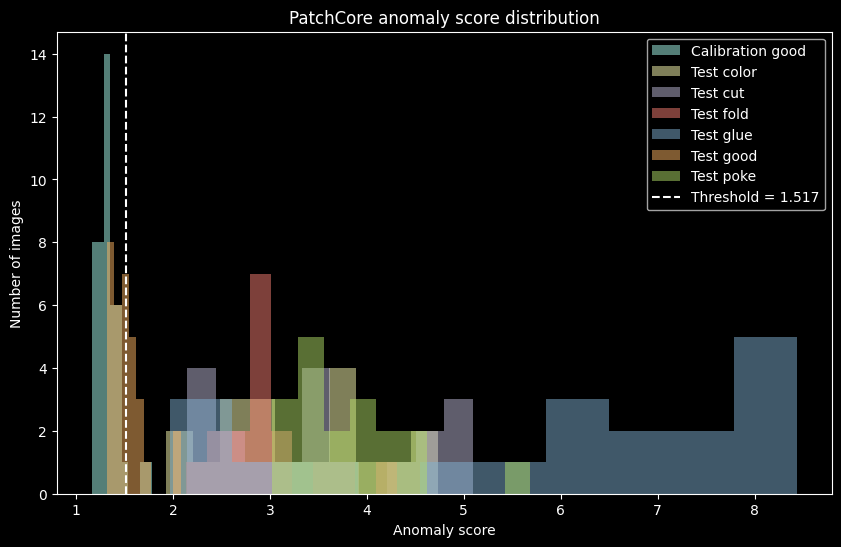

In [63]:
import matplotlib.pyplot as plt

# Calibration 正常分数
calibration_values = calibration_scores.numpy()

# Test 各类别分数
scores_by_type = {}

for item in patch_results:
    defect_type = item["type"]

    if defect_type not in scores_by_type:
        scores_by_type[defect_type] = []

    scores_by_type[defect_type].append(item["score"])


plt.figure(figsize=(10, 6))

# Calibration 正常集
plt.hist(
    calibration_values,
    bins=10,
    alpha=0.6,
    label="Calibration good"
)

# Test 各类别
for defect_type, scores in scores_by_type.items():
    plt.hist(
        scores,
        bins=10,
        alpha=0.5,
        label=f"Test {defect_type}"
    )

# 候选 threshold
threshold = torch.quantile(
    calibration_scores,
    0.95
).item()

plt.axvline(
    threshold,
    linestyle="--",
    label=f"Threshold = {threshold:.3f}"
)

plt.xlabel("Anomaly score")
plt.ylabel("Number of images")
plt.title("PatchCore anomaly score distribution")
plt.legend()
plt.show()

然后我们用新的到的阈值 再看看在test数据集上表现如何

In [64]:
threshold = torch.quantile(
    calibration_scores,
    0.95
).item()

tp = 0
tn = 0
fp = 0
fn = 0

for item in patch_results:

    score = item["score"]

    # MVTec:
    # label = 0 → good
    # label = 1 → defect
    predicted_anomaly = score > threshold
    actual_anomaly = item["label"] == 1

    if predicted_anomaly and actual_anomaly:
        tp += 1

    elif predicted_anomaly and not actual_anomaly:
        fp += 1

    elif not predicted_anomaly and not actual_anomaly:
        tn += 1

    elif not predicted_anomaly and actual_anomaly:
        fn += 1


precision = tp / (tp + fp) if tp + fp > 0 else 0
recall = tp / (tp + fn) if tp + fn > 0 else 0
f1 = (
    2 * precision * recall / (precision + recall)
    if precision + recall > 0
    else 0
)

print("Threshold:", threshold)
print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Threshold: 1.5172061920166016
TP: 92
TN: 20
FP: 12
FN: 0
Precision: 0.8846153846153846
Recall: 1.0
F1: 0.9387755102040816


现在固化阈值1.51 分析当前模型效果：
召回率高，所以异常都检测出来了。但是good的误检率高，有12个，这个比例远高于我们用验证集实验的数据，所以这个时候我们要看看这FP的
图片都有哪些，看看和训练集的数据有什么区别，如果肉眼实在看不出来，就用热力图观察。

In [65]:
false_positives = [
    item for item in patch_results
    if item["label"] == 0 and item["score"] > threshold
]

print("False Positives:", len(false_positives))

for item in sorted(
    false_positives,
    key=lambda x: x["score"],
    reverse=True
):
    print(
        f"{item['score']:.4f}  {item['path']}"
    )

False Positives: 12
2.0821  dataset/leather/test/good/013.png
2.0318  dataset/leather/test/good/029.png
1.7596  dataset/leather/test/good/005.png
1.6746  dataset/leather/test/good/000.png
1.6713  dataset/leather/test/good/016.png
1.6452  dataset/leather/test/good/009.png
1.6164  dataset/leather/test/good/012.png
1.5986  dataset/leather/test/good/010.png
1.5965  dataset/leather/test/good/004.png
1.5828  dataset/leather/test/good/015.png
1.5488  dataset/leather/test/good/011.png
1.5267  dataset/leather/test/good/031.png
